### Building chatbots using LangGraph 


A chatbot is just an iterative workflow — user sends a query, LLM responds, repeat. 

- User → LLM → Response → User → LLM → ...

We'll build this step by step covering: Chat, RAG, Tools, Memory & Persistence, and Streaming.


In a chatbot, state = the conversation history (all messages so far).

In [10]:
from typing import Annotated, TypedDict
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import StateGraph, add_messages, START, END

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

add_messages tells LangGraph: "don't replace the list, just append to it."

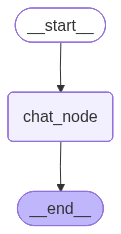

In [11]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=1.0)

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

def chat_node(state: ChatState):
    messages = state['messages']      # full conversation history
    response = llm.invoke(messages)   # LLM sees entire history
    return {"messages": [response]}   # add_messages appends this automatically

graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

chatbot = graph.compile()
chatbot

In [14]:
while True:
    u = input("Type here: ")
    if u.strip().lower() in ['exit', 'bye', 'quit']:
        break
    r = chatbot.invoke({"messages": [HumanMessage(content=u)]})
    print("Human:", u)
    print("AI:", r['messages'][-1].content)
    print("-" * 50)

Human: my name is shubh
AI: Hi Shubh! It's nice to meet you.
--------------------------------------------------
Human: whats my name?
AI: I don't know your name. As an AI, I don't have access to personal information about you.

How can I help you today?
--------------------------------------------------


Big problem — this chatbot is STATELESS. 

Every time the user sends a message → it becomes a separate, independent workflow invocation → chatbot has no memory of previous turns.
Why? Because as soon as the workflow reaches END, the state is discarded.

**Persistence to the Rescue**: Persistence = when the workflow reaches END, instead of discarding state, we save it somewhere.

Two options:
1. RAM → InMemorySaver (lost when program stops)
2. Database → SqliteSaver / PostgresSaver (permanent)

In [15]:
from langgraph.checkpoint.memory import InMemorySaver


llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=1.0)

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

def chat_node(state: ChatState):
    messages = state['messages']      # full conversation history
    response = llm.invoke(messages)   # LLM sees entire history
    return {"messages": [response]}   # add_messages appends this automatically

graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

checkpointer = InMemorySaver()
chatbot = graph.compile(checkpointer=checkpointer)  # attach persistence here

With persistence, LangGraph needs to know which conversation to load from memory. That's what thread_id is for.

Same thread_id = same conversation history loaded. Different thread_id = fresh conversation.

In [16]:
thread_id = 1234

while True:
    u = input("Type here: ")
    if u.strip().lower() in ['exit', 'bye', 'quit']:
        break
    config = {'configurable': {'thread_id': thread_id}} # pass thread_id in config
    r = chatbot.invoke({"messages": [HumanMessage(content=u)]}, config=config)
    print("Human:", u)
    print("AI:", r['messages'][-1].content)
    print("-" * 50)

Human: My name is shubh
AI: Hi Shubh! Nice to meet you.
--------------------------------------------------
Human: whats my name?
AI: Your name is Shubh!
--------------------------------------------------


Now every invocation loads previous messages for that thread → **chatbot has memory** ✅

Let's try adding the streaming effect in our chatbot.

Without streaming:

```
pythonresponse = chatbot.invoke(...)
print(response)   # waits 5 seconds... then prints everything at once
```

User stares at a blank screen for 5 seconds. Bad experience.
Streaming = print each word/token as it's generated, like ChatGPT's typewriter effect.

In [ ]:
thread_id = 1234

while True:
    u = input("You: ")
    if u.strip().lower() in ['exit', 'bye', 'quit']:
        break

    config = {'configurable': {'thread_id': thread_id}}

    print("AI: ", end="", flush=True)

    for message_chunk, metadata in chatbot.stream(
        {"messages": [HumanMessage(content=u)]},
        config=config,
        stream_mode="messages"
    ):
        print(message_chunk.content, end="", flush=True)

    print()          
    print("-" * 50)


    # NOTE : For small outputs u might not see the streaming effect because the entire response fits in a single chunk. 
    # To test streaming, try asking a question that requires a long response, e.g. "Explain quantum mechanics in simple terms."

AI: Got it! Thanks for confirming, Shubh. It's a pleasure to chat with you.
--------------------------------------------------
AI: Wassup, Shubh! Yes, I do know your name. Glad to chat with you again!
--------------------------------------------------


### Human in the Loop

Human in the Loop = pausing the graph mid-execution to let a human review, approve, or modify before continuing.

How LangGraph implements this — interrupt() function that halts execution and waits for user input.
LangGraph has a built-in mechanism to pause at a node and wait for human input.

```
from langgraph.types import interrupt

def human_review_node(state):
    result = interrupt({
        "question": "Do you approve this?",
        "data": state['draft']
    })
    return {"approval": result}
```

Resuming the graph — Command
After the human responds, you resume using Command:

```
from langgraph.types import Command

# Resume with human's input
chatbot.invoke(
    Command(resume="approved"),   # human's response goes here
    config=config
)
```

**Full Example — Tweet Approval System**

In [23]:
from typing import TypedDict

class TweetState(TypedDict):
    topic: str
    draft: str
    feedback: str
    final: str

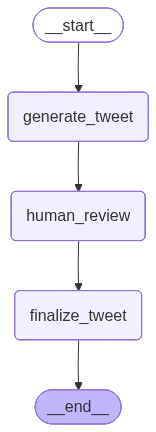

In [24]:
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver

def generate_tweet(state):
    response = llm.invoke(f"Write a tweet about {state['topic']} in 1 line.")
    return {"draft": response.content}

def human_review(state):
    print(f"\n📝 Draft Tweet:\n{state['draft']}")
    result = interrupt("Do you approve? (yes/no + feedback)")
    return {"feedback": result}

def finalize_tweet(state):
    if state['feedback'].lower() == 'yes':
        return {"final": state['draft']}
    else:
        # rewrite based on feedback
        response = llm.invoke(
            f"Rewrite this tweet: {state['draft']}\nFeedback: {state['feedback']}"
        )
        return {"final": response.content}

graph = StateGraph(TweetState)
graph.add_node("generate_tweet", generate_tweet)
graph.add_node("human_review", human_review)
graph.add_node("finalize_tweet", finalize_tweet)

graph.add_edge(START, "generate_tweet")
graph.add_edge("generate_tweet", "human_review")
graph.add_edge("human_review", "finalize_tweet")
graph.add_edge("finalize_tweet", END)

checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)  # ✅ needs checkpointer
workflow

In [ ]:
initial_state = {
    "topic": "AGI",
    "draft": "",
    "feedback": "",
    "final": ""
}

config = {"configurable": {"thread_id": "1"}}

# Step 1 — run until interrupt
result = workflow.invoke(initial_state, config=config)

# Step 2 —  take human input
human_input = input("Approve or give feedback: ")  # ✅ actually take input here

# Step 3 — resume with human's input
final = workflow.invoke(
    Command(resume=human_input),   # ✅ pass actual input
    config=config
)

print("\n✅ Final Tweet:")
print(final['final'])


📝 Draft Tweet:
AGI: Humanity's next chapter just began.

📝 Draft Tweet:
AGI: Humanity's next chapter just began.
--------------------------------------------------

📝 Draft Tweet:
AGI: Humanity's next chapter just began.

✅ Final Tweet:
Okay, since the original tweet was "approved," the goal is to offer variations that maintain the positive, forward-looking, and impactful tone, but perhaps with slightly different wording, emphasis, or tweet-friendly elements.

Here are a few options, keeping the essence of the original:

1.  **Slightly more active:**
    AGI: Humanity's next chapter begins now.

2.  **Emphasizing arrival:**
    AGI has arrived. A new chapter for humanity officially starts.

3.  **More evocative:**
    AGI: The dawn of humanity's most transformative chapter.

4.  **Punchier with emoji/hashtag:**
    AGI is here. 🚀 Humanity's next chapter just opened! #FutureIsAGI

5.  **Focus on potential:**
    AGI: Humanity's greatest possibilities are just beginning to unfold.
